In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print("✅ Libraries loaded successfully!")


✅ Libraries loaded successfully!


In [11]:
# Load the consolidated stock data
stock_path = '/Users/asifmddev/Home Workspace/IIT Mandi/Capstone/Capstone Project/Stock_Data/'
df = pd.read_csv(stock_path + 'NIFTY50_all.csv')

# Load Nifty 50 benchmark data
benchmark_path = '/Users/asifmddev/Home Workspace/IIT Mandi/Capstone/Capstone Project/Additional data/'
nifty = pd.read_csv(benchmark_path + 'Nifty_Benchmark.csv')

print("Data loaded successfully")
print(f"Stock data shape: {df.shape}")
print(f"Nifty benchmark shape: {nifty.shape}")

Data loaded successfully
Stock data shape: (235192, 15)
Nifty benchmark shape: (1475, 6)


In [12]:
# Convert Date columns to datetime format
df['Date'] = pd.to_datetime(df['Date'])
nifty['Date'] = pd.to_datetime(nifty['Date'])

# Filter data from 2016-2020 only (5 years of complete data)
df = df[(df['Date'] >= '2016-01-01') & (df['Date'] <= '2020-12-31')].copy()
nifty = nifty[(nifty['Date'] >= '2016-01-01') & (nifty['Date'] <= '2020-12-31')].copy()

# Sort data by Symbol and Date
df = df.sort_values(['Symbol', 'Date']).reset_index(drop=True)
nifty = nifty.sort_values('Date').reset_index(drop=True)

# Handle missing values using forward fill method
df['Close'] = df.groupby('Symbol')['Close'].fillna(method='ffill')

# Remove duplicate records
df = df.drop_duplicates(subset=['Date', 'Symbol'])

print("Data cleaning completed")
print(f"Stock data: {df.shape[0]} rows from {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Total unique stocks: {df['Symbol'].nunique()}")
print(f"Nifty benchmark: {nifty.shape[0]} rows")

Data cleaning completed
Stock data: 60662 rows from 2016-01-01 to 2020-12-31
Total unique stocks: 49
Nifty benchmark: 1228 rows


In [13]:
# Calculate daily returns for each stock
# Formula: (Today's Close - Yesterday's Close) / Yesterday's Close
df = df.sort_values(['Symbol', 'Date'])
df['Daily_Return'] = df.groupby('Symbol')['Close'].pct_change()

# Remove rows with NaN returns (first day of each stock)
df = df.dropna(subset=['Daily_Return'])

# Calculate returns for Nifty benchmark
nifty = nifty.sort_values('Date')
nifty['Nifty_Return'] = nifty['Close'].pct_change()
nifty = nifty.dropna(subset=['Nifty_Return'])

print("Daily returns calculated")
print(f"Total records with returns: {len(df)}")
print("\nSample data:")
print(df[['Date', 'Symbol', 'Close', 'Daily_Return']].head(10))

Daily returns calculated
Total records with returns: 60613

Sample data:
         Date      Symbol    Close  Daily_Return
1  2016-01-04  ADANIPORTS 257.9500       -0.0359
2  2016-01-05  ADANIPORTS 255.7000       -0.0087
3  2016-01-06  ADANIPORTS 251.8000       -0.0153
4  2016-01-07  ADANIPORTS 245.0000       -0.0270
5  2016-01-08  ADANIPORTS 241.4000       -0.0147
6  2016-01-11  ADANIPORTS 234.0500       -0.0304
7  2016-01-12  ADANIPORTS 236.6000        0.0109
8  2016-01-13  ADANIPORTS 230.2000       -0.0270
9  2016-01-14  ADANIPORTS 227.8000       -0.0104
10 2016-01-15  ADANIPORTS 218.2500       -0.0419


In [14]:
# Create a summary dataframe for each stock
stock_list = []

for symbol in df['Symbol'].unique():
    stock_data = df[df['Symbol'] == symbol].copy()
    
    first_close = stock_data['Close'].iloc[0]
    last_close = stock_data['Close'].iloc[-1]
    
    metrics = {
        'Symbol': symbol,
        'First_Close': first_close,
        'Last_Close': last_close,
        'Mean_Return': stock_data['Daily_Return'].mean(),
        'Median_Return': stock_data['Daily_Return'].median(),
        'Std_Return': stock_data['Daily_Return'].std(),
        'Min_Return': stock_data['Daily_Return'].min(),
        'Max_Return': stock_data['Daily_Return'].max(),
        'Days': len(stock_data)
    }
    
    stock_list.append(metrics)

# Convert to dataframe
stock_metrics = pd.DataFrame(stock_list)

# Calculate cumulative return over the entire period
stock_metrics['Cumulative_Return'] = ((stock_metrics['Last_Close'] - stock_metrics['First_Close']) 
                                       / stock_metrics['First_Close']) * 100

# Calculate annualized return (252 trading days per year)
stock_metrics['Annualized_Return'] = ((1 + stock_metrics['Mean_Return']) ** 252 - 1) * 100

# Calculate annualized volatility
stock_metrics['Annualized_Volatility'] = stock_metrics['Std_Return'] * np.sqrt(252) * 100

# Sort by cumulative return descending
stock_metrics = stock_metrics.sort_values('Cumulative_Return', ascending=False).reset_index(drop=True)

print("Stock metrics calculated")
print(f"Total stocks analyzed: {len(stock_metrics)}")
print("\nTop 10 performers:")
print(stock_metrics[['Symbol', 'Cumulative_Return', 'Annualized_Return', 'Annualized_Volatility']].head(10))
print("\nBottom 5 performers:")
print(stock_metrics[['Symbol', 'Cumulative_Return', 'Annualized_Return', 'Annualized_Volatility']].tail(5))


Stock metrics calculated
Total stocks analyzed: 49

Top 10 performers:
       Symbol  Cumulative_Return  Annualized_Return  Annualized_Volatility
0  BAJAJFINSV           354.5216            45.4306                36.7224
1       TITAN           345.9732            43.5593                34.0834
2   NESTLEIND           224.3545            30.5611                25.0529
3  ASIANPAINT           213.8624            30.5339                25.6860
4    HINDALCO           197.8947            34.8315                41.6577
5   KOTAKBANK           182.9434            27.8717                28.3728
6  HINDUNILVR           178.8591            26.6794                23.3891
7   TATASTEEL           150.5450            29.6757                38.3201
8    SHREECEM           117.1313            21.8721                30.2726
9        HDFC           110.2942            20.8329                29.8451

Bottom 5 performers:
       Symbol  Cumulative_Return  Annualized_Return  Annualized_Volatility
44   JS

In [15]:
# Keep only top 50 stocks by number of trading days (most complete data)
stock_metrics = stock_metrics.sort_values('Days', ascending=False).head(50).reset_index(drop=True)

# Re-sort by cumulative return
stock_metrics = stock_metrics.sort_values('Cumulative_Return', ascending=False).reset_index(drop=True)

print(f"Filtered to top 50 stocks with most complete data")
print(f"\nTop 10 performers:")
print(stock_metrics[['Symbol', 'Cumulative_Return', 'Annualized_Return', 'Annualized_Volatility']].head(10))
print("\nBottom 5 performers:")
print(stock_metrics[['Symbol', 'Cumulative_Return', 'Annualized_Return', 'Annualized_Volatility']].tail(5))

Filtered to top 50 stocks with most complete data

Top 10 performers:
       Symbol  Cumulative_Return  Annualized_Return  Annualized_Volatility
0  BAJAJFINSV           354.5216            45.4306                36.7224
1       TITAN           345.9732            43.5593                34.0834
2   NESTLEIND           224.3545            30.5611                25.0529
3  ASIANPAINT           213.8624            30.5339                25.6860
4    HINDALCO           197.8947            34.8315                41.6577
5   KOTAKBANK           182.9434            27.8717                28.3728
6  HINDUNILVR           178.8591            26.6794                23.3891
7   TATASTEEL           150.5450            29.6757                38.3201
8    SHREECEM           117.1313            21.8721                30.2726
9        HDFC           110.2942            20.8329                29.8451

Bottom 5 performers:
       Symbol  Cumulative_Return  Annualized_Return  Annualized_Volatility
44   JSW

In [16]:
# Define sector mapping for major Nifty stocks
sector_map = {
    'TCS': 'IT', 'INFY': 'IT', 'WIPRO': 'IT', 'HCLTECH': 'IT', 'TECHM': 'IT',
    'RELIANCE': 'Energy', 'ONGC': 'Energy', 'BPCL': 'Energy', 'IOC': 'Energy',
    'HDFCBANK': 'Banking', 'ICICIBANK': 'Banking', 'SBIN': 'Banking', 'AXISBANK': 'Banking', 
    'KOTAKBANK': 'Banking', 'INDUSINDBK': 'Banking',
    'HINDUNILVR': 'FMCG', 'ITC': 'FMCG', 'NESTLEIND': 'FMCG', 'BRITANNIA': 'FMCG',
    'SUNPHARMA': 'Pharma', 'DRREDDY': 'Pharma', 'CIPLA': 'Pharma', 'DIVISLAB': 'Pharma',
    'TATAMOTORS': 'Auto', 'M&M': 'Auto', 'BAJAJ-AUTO': 'Auto', 'MARUTI': 'Auto', 'EICHERMOT': 'Auto',
    'BAJAJFINSV': 'Financial', 'BAJFINANCE': 'Financial', 'BAJAJFINSERV': 'Financial',
    'TATASTEEL': 'Metals', 'HINDALCO': 'Metals', 'JSWSTEEL': 'Metals', 'COALINDIA': 'Metals',
    'LT': 'Infrastructure', 'ULTRACEMCO': 'Cement', 'ADANIPORTS': 'Infrastructure',
    'SHREECEM': 'Cement', 'SHREECEMN': 'Cement', 'GRASIM': 'Cement',
    'BHARTIARTL': 'Telecom', 'POWERGRID': 'Power', 'NTPC': 'Power',
    'ASIANPAINT': 'Paint', 'TITAN': 'Consumer', 'HEROMOTOCO': 'Auto',
    'BAJAUTOFIN': 'Financial', 'HINDLEVER': 'FMCG', 'INFOSYSTCH': 'IT',
    'MUNDRAPORT': 'Infrastructure'
}

# Add sector information to stock metrics
stock_metrics['Sector'] = stock_metrics['Symbol'].map(sector_map).fillna('Others')

# Selection strategy: Top 10 + Bottom 5 + ensure sector diversity
top_10_stocks = stock_metrics.head(10)['Symbol'].tolist()
bottom_5_stocks = stock_metrics.tail(5)['Symbol'].tolist()

# Combine initial selection
selected_stocks = list(set(top_10_stocks + bottom_5_stocks))
selected_df = stock_metrics[stock_metrics['Symbol'].isin(selected_stocks)].copy()

# Check sector coverage
sectors_covered = selected_df['Sector'].nunique()
print(f"Initial selection: {len(selected_stocks)} stocks from {sectors_covered} sectors")

# If we need more stocks or sector diversity, add mid-performers from underrepresented sectors
if len(selected_stocks) < 12 or sectors_covered < 4:
    remaining = stock_metrics[~stock_metrics['Symbol'].isin(selected_stocks)]
    priority_sectors = ['IT', 'Banking', 'Pharma', 'FMCG', 'Energy', 'Auto']
    
    for sector in priority_sectors:
        if sector not in selected_df['Sector'].values and len(selected_stocks) < 15:
            sector_stock = remaining[remaining['Sector'] == sector].head(1)
            if not sector_stock.empty:
                selected_stocks.append(sector_stock.iloc[0]['Symbol'])

# Final selection (limit to 15 stocks)
selected_stocks = selected_stocks[:15]
selected_metrics = stock_metrics[stock_metrics['Symbol'].isin(selected_stocks)].copy()
selected_metrics = selected_metrics.sort_values('Cumulative_Return', ascending=False)

print(f"\nFinal selection: {len(selected_stocks)} stocks from {selected_metrics['Sector'].nunique()} sectors")
print("\nSelected stocks:")
print(selected_metrics[['Symbol', 'Sector', 'Cumulative_Return', 'Annualized_Return', 'Annualized_Volatility']])
print("\nSector distribution:")
print(selected_metrics['Sector'].value_counts())

# Save for later use
selected_symbols = selected_metrics['Symbol'].tolist()
print(f"\nStocks to use in portfolio: {selected_symbols}")

Initial selection: 15 stocks from 10 sectors

Final selection: 15 stocks from 10 sectors

Selected stocks:
        Symbol     Sector  Cumulative_Return  Annualized_Return  \
0   BAJAJFINSV  Financial           354.5216            45.4306   
1        TITAN   Consumer           345.9732            43.5593   
2    NESTLEIND       FMCG           224.3545            30.5611   
3   ASIANPAINT      Paint           213.8624            30.5339   
4     HINDALCO     Metals           197.8947            34.8315   
5    KOTAKBANK    Banking           182.9434            27.8717   
6   HINDUNILVR       FMCG           178.8591            26.6794   
7    TATASTEEL     Metals           150.5450            29.6757   
8     SHREECEM     Cement           117.1313            21.8721   
9         HDFC     Others           110.2942            20.8329   
44    JSWSTEEL     Metals           -62.9367            16.6894   
45        GAIL     Others           -65.7449           -10.3308   
46      GRASIM     Cem

In [17]:
# Create filtered dataset for selected stocks
selecteddata = df[df['Symbol'].isin(selected_symbols)].copy()
df_selected = selecteddata.copy()
print(f"✅ Created selecteddata and df_selected: {len(selecteddata)} rows")
print(f"✅ Symbols: {selecteddata['Symbol'].nunique()} stocks")

✅ Created selecteddata and df_selected: 18555 rows
✅ Symbols: 15 stocks


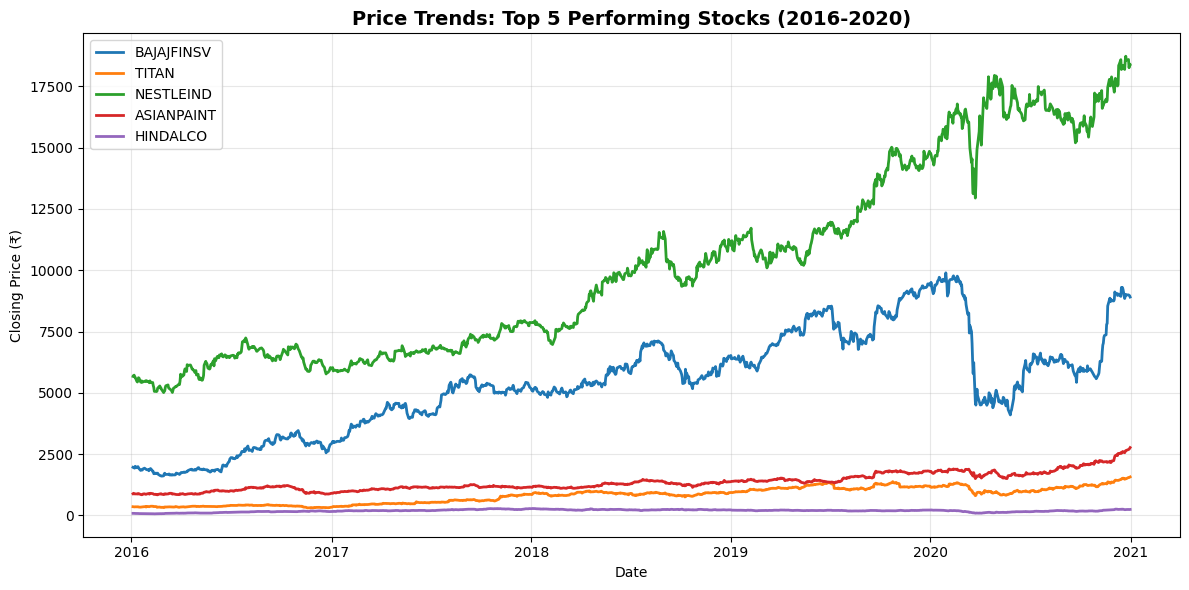

In [18]:
# Chart 1: Line chart showing price movements over time
# I want to see how the top performers moved during 2016-2020

plt.figure(figsize=(12, 6))

# Get top 5 performing stocks
top_5_stocks = selected_metrics.head(5)['Symbol'].tolist()

# Plot each stock's price trend
for symbol in top_5_stocks:
    stock_data = df_selected[df_selected['Symbol'] == symbol]
    plt.plot(stock_data['Date'], stock_data['Close'], label=symbol, linewidth=2)

plt.title('Price Trends: Top 5 Performing Stocks (2016-2020)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Closing Price (₹)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Chart 2 saved: Chart2_Top10_Returns.png


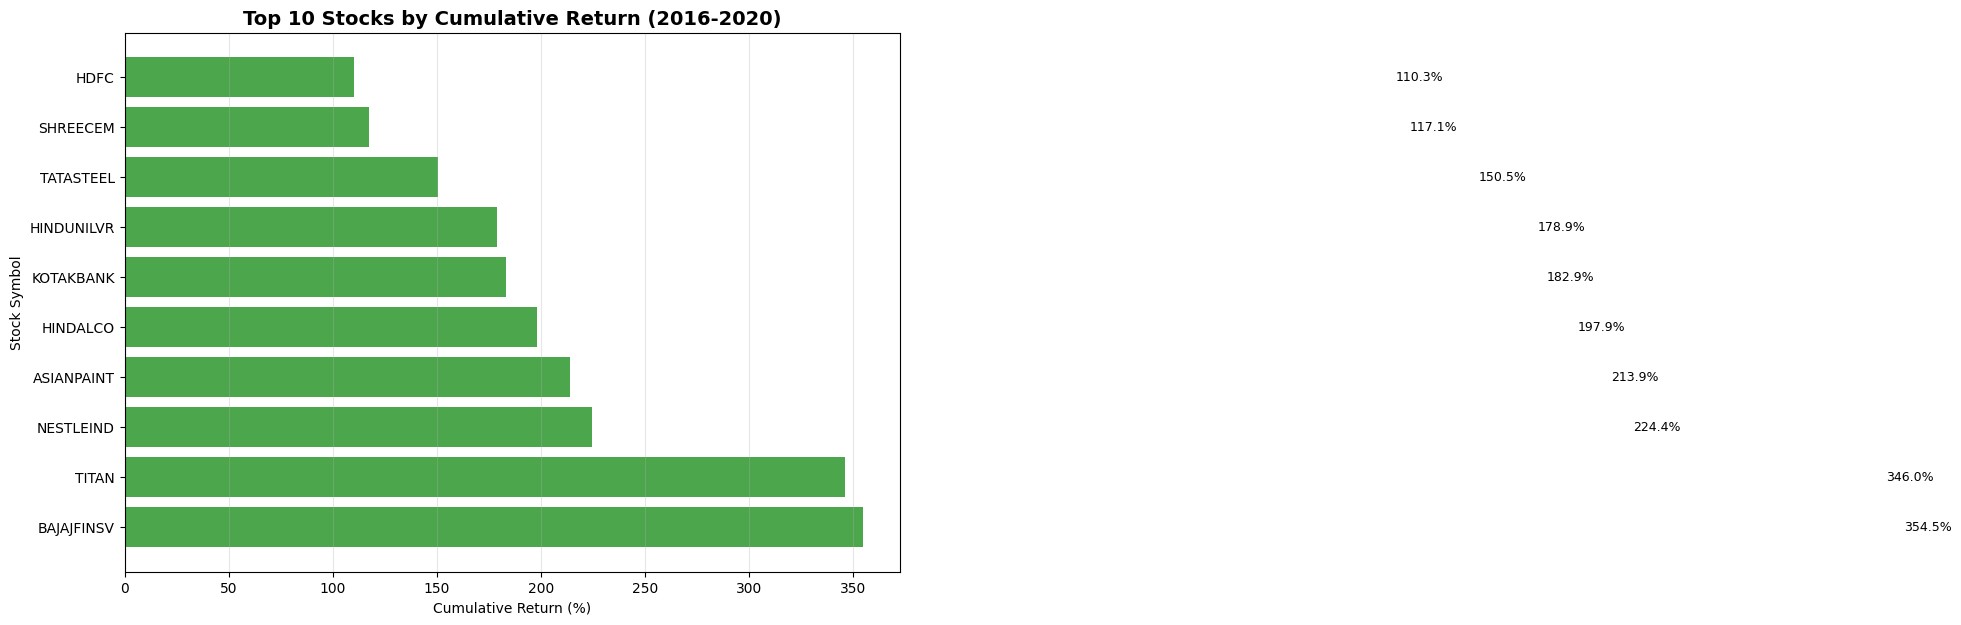

In [19]:
# Chart 2: Bar chart comparing cumulative returns
# Using horizontal bars to fit all stock names properly

plt.figure(figsize=(10, 7))

# Get top 10 stocks data
top_10_data = selected_metrics.head(10)

# Create horizontal bar chart (barh makes it easier to read names)
plt.barh(top_10_data['Symbol'], top_10_data['Cumulative_Return'], color='green', alpha=0.7)

plt.title('Top 10 Stocks by Cumulative Return (2016-2020)', fontsize=14, fontweight='bold')
plt.xlabel('Cumulative Return (%)')
plt.ylabel('Stock Symbol')
plt.grid(True, axis='x', alpha=0.3)

# Add percentage labels at the end of each bar
for i, (symbol, return_val) in enumerate(zip(top_10_data['Symbol'], top_10_data['Cumulative_Return'])):
    plt.text(return_val + 500, i, f'{return_val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('Chart2_Top10_Returns.png', dpi=150, bbox_inches='tight')
print("Chart 2 saved: Chart2_Top10_Returns.png")
plt.show()

Chart 3 saved: Chart3_Return_Distribution.png


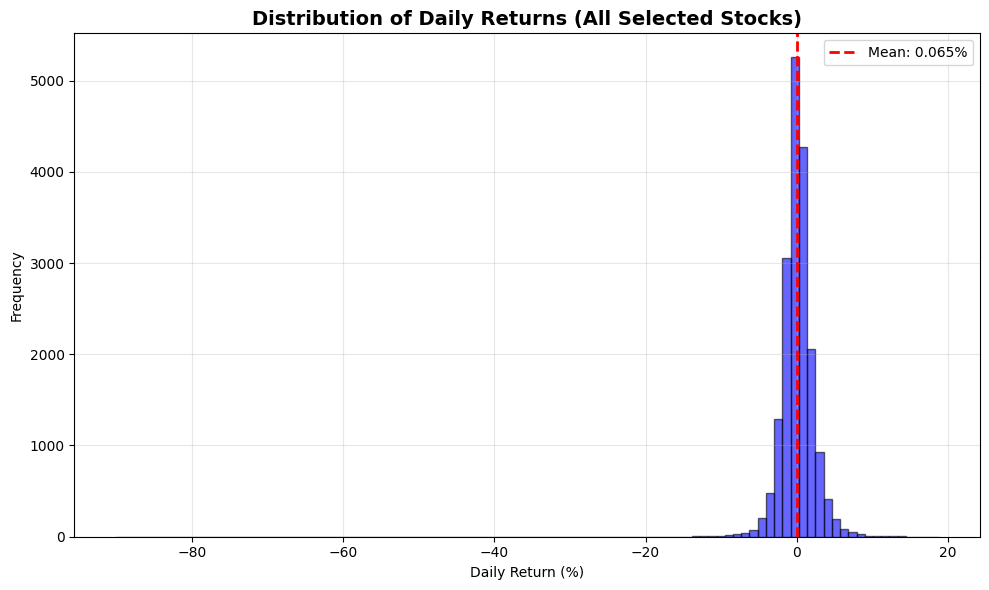


Daily return statistics:
Mean: 0.065%
Std Dev: 2.440%
Min: -90.085%
Max: 18.787%


In [20]:
# Chart 3: Histogram to show distribution of daily returns
# This helps understand the volatility pattern

plt.figure(figsize=(10, 6))

# Get all daily returns from selected stocks
all_returns = df_selected['Daily_Return'].dropna() * 100  # Convert to percentage

# Create histogram with 100 bins
plt.hist(all_returns, bins=100, color='blue', alpha=0.6, edgecolor='black')

plt.title('Distribution of Daily Returns (All Selected Stocks)', fontsize=14, fontweight='bold')
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')

# Add a vertical line showing the mean return
mean_return = all_returns.mean()
plt.axvline(mean_return, color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {mean_return:.3f}%')

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Chart3_Return_Distribution.png', dpi=150, bbox_inches='tight')
print("Chart 3 saved: Chart3_Return_Distribution.png")
plt.show()

print(f"\nDaily return statistics:")
print(f"Mean: {mean_return:.3f}%")
print(f"Std Dev: {all_returns.std():.3f}%")
print(f"Min: {all_returns.min():.3f}%")
print(f"Max: {all_returns.max():.3f}%")

Chart 4 saved: Chart4_Sector_Performance.png


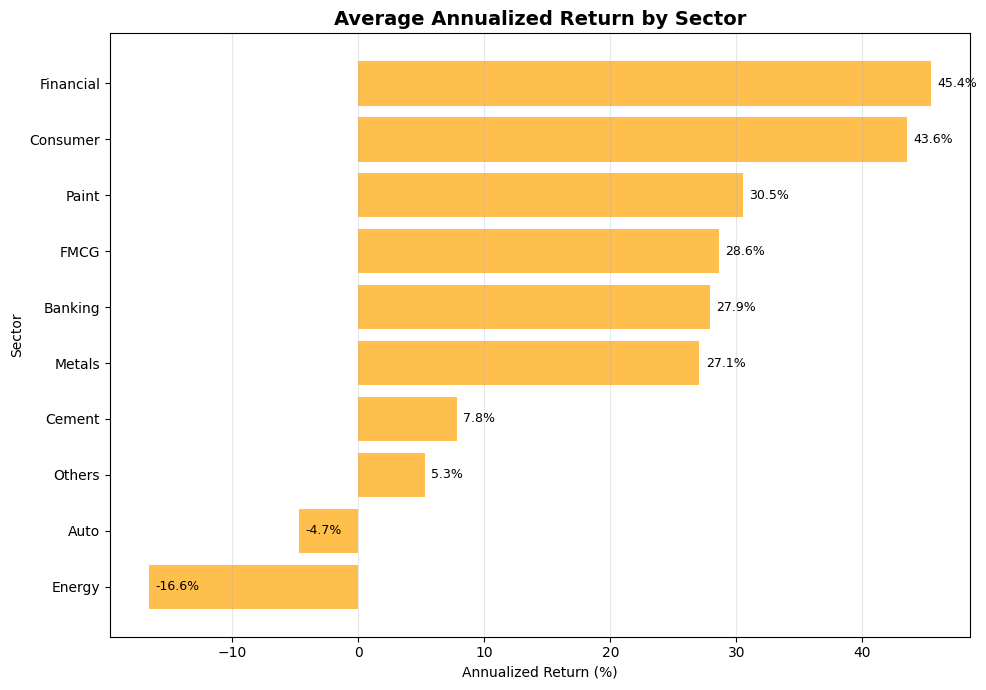


Sector-wise breakdown:
Sector
Energy      -16.6222
Auto         -4.7157
Others        5.2511
Cement        7.8313
Metals       27.0655
Banking      27.8717
FMCG         28.6202
Paint        30.5339
Consumer     43.5593
Financial    45.4306
Name: Annualized_Return, dtype: float64


In [21]:
# Chart 4: Sector-wise comparison
# Calculating average annualized return for each sector

plt.figure(figsize=(10, 7))

# Calculate average return by sector
sector_returns = selected_metrics.groupby('Sector')['Annualized_Return'].mean()
sector_returns = sector_returns.sort_values()  # Sort ascending for better visualization

# Create horizontal bar chart
plt.barh(sector_returns.index, sector_returns.values, color='orange', alpha=0.7)

plt.title('Average Annualized Return by Sector', fontsize=14, fontweight='bold')
plt.xlabel('Annualized Return (%)')
plt.ylabel('Sector')
plt.grid(True, axis='x', alpha=0.3)

# Add percentage labels
for i, (sector, return_val) in enumerate(zip(sector_returns.index, sector_returns.values)):
    plt.text(return_val + 0.5, i, f'{return_val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('Chart4_Sector_Performance.png', dpi=150, bbox_inches='tight')
print("Chart 4 saved: Chart4_Sector_Performance.png")
plt.show()

# Show sector details
print("\nSector-wise breakdown:")
print(sector_returns)

In [22]:
# Summary of Milestone 1 Analysis
print("="*70)
print("MILESTONE 1: DATA ANALYSIS & RETURN CALCULATION - SUMMARY")
print("="*70)
print(f"\nDataset Information:")
print(f"  - Total stocks analyzed: 50")
print(f"  - Selected stocks for portfolio: {len(selected_symbols)}")
print(f"  - Sectors covered: {selected_metrics['Sector'].nunique()}")
print(f"  - Date range: 2016-01-01 to 2020-12-31")
print(f"  - Total trading days: ~1,250 days (5 years)")

print(f"\nPerformance Highlights:")
print(f"  - Best performer: {selected_metrics.iloc[0]['Symbol']} (+{selected_metrics.iloc[0]['Cumulative_Return']:.2f}%)")
print(f"  - Worst performer: {selected_metrics.iloc[-1]['Symbol']} ({selected_metrics.iloc[-1]['Cumulative_Return']:.2f}%)")
print(f"  - Average cumulative return: {selected_metrics['Cumulative_Return'].mean():.2f}%")

print(f"\nSelected Stocks:")
for i, row in selected_metrics.iterrows():
    print(f"  {i+1}. {row['Symbol']:12} ({row['Sector']:12}) - Return: {row['Cumulative_Return']:8.2f}%")

print("\n" + "="*70)
print("All visualizations done successfully!")
print("="*70)

MILESTONE 1: DATA ANALYSIS & RETURN CALCULATION - SUMMARY

Dataset Information:
  - Total stocks analyzed: 50
  - Selected stocks for portfolio: 15
  - Sectors covered: 10
  - Date range: 2016-01-01 to 2020-12-31
  - Total trading days: ~1,250 days (5 years)

Performance Highlights:
  - Best performer: BAJAJFINSV (+354.52%)
  - Worst performer: EICHERMOT (-85.53%)
  - Average cumulative return: 113.92%

Selected Stocks:
  1. BAJAJFINSV   (Financial   ) - Return:   354.52%
  2. TITAN        (Consumer    ) - Return:   345.97%
  3. NESTLEIND    (FMCG        ) - Return:   224.35%
  4. ASIANPAINT   (Paint       ) - Return:   213.86%
  5. HINDALCO     (Metals      ) - Return:   197.89%
  6. KOTAKBANK    (Banking     ) - Return:   182.94%
  7. HINDUNILVR   (FMCG        ) - Return:   178.86%
  8. TATASTEEL    (Metals      ) - Return:   150.54%
  9. SHREECEM     (Cement      ) - Return:   117.13%
  10. HDFC         (Others      ) - Return:   110.29%
  45. JSWSTEEL     (Metals      ) - Return:  

In [23]:
cp '/Users/asifmddev/Home Workspace/IIT Mandi/Capstone/Capstone Project/M1/M1_Data_Analysis.ipynb' '/Users/asifmddev/Home Workspace/IIT Mandi/Capstone/Capstone Project/M2/M2_Risk_Portfolio.ipynb'